<a href="https://colab.research.google.com/github/Alishba-12/AI-ML_01_ImageClassification_byte./blob/main/Cats_vs_Dogs_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch torchvision matplotlib seaborn scikit-learn pillow tqdm opencv-python

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os
import random
from tqdm import tqdm
import zipfile
from datetime import datetime
import shutil

In [9]:
# DOWNLOAD DATASET
print("📥 Downloading dataset...")

# Create directories
!mkdir -p data/cats data/dogs

# Download the files
!wget -O dogs.zip https://github.com/dataprofessor/data/raw/master/dogs.zip
!wget -O cats.zip https://github.com/dataprofessor/data/raw/master/cats.zip

# Extract files
print("📂 Extracting cats...")
!unzip -q cats.zip -d data/

print("📂 Extracting dogs...")
!unzip -q dogs.zip -d data/

# ORGANIZE THE FILES - This is the important part!
import os
import shutil

print("\n🔍 Checking folder structure...")

# Check what was extracted
print("Contents of data/ after extraction:")
!ls -la data/

# Function to move images from subfolders to the right place
def organize_images(source_dir, target_dir, class_name):
    """Move images from nested folders to target directory"""
    os.makedirs(target_dir, exist_ok=True)

    # Check if source directory exists
    if not os.path.exists(source_dir):
        print(f"⚠️ Source directory {source_dir} not found")
        return 0

    moved_count = 0

    # Walk through all subdirectories
    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):
                source_path = os.path.join(root, file)
                dest_path = os.path.join(target_dir, f"{class_name}_{moved_count}_{file}")
                shutil.move(source_path, dest_path)
                moved_count += 1

    print(f"✅ Moved {moved_count} {class_name} images to {target_dir}")
    return moved_count

# Move cat images to data/cats/
cat_source = 'data/cats'  # The folder that was created
cat_moved = organize_images(cat_source, 'data/cats', 'cat')

# Move dog images to data/dogs/
dog_source = 'data/dogs'  # The folder that was created
dog_moved = organize_images(dog_source, 'data/dogs', 'dog')

# Clean up empty directories
print("\n🧹 Cleaning up...")
!rm -rf data/cats/__MACOSX 2>/dev/null
!rm -rf data/dogs/__MACOSX 2>/dev/null

# Remove zip files
!rm -f cats.zip dogs.zip sample_data.zip

print("\n" + "="*50)
print("📊 DATASET SUMMARY")
print("="*50)
print(f"🐱 Cats images: {len(os.listdir('data/cats'))}")
print(f"🐶 Dogs images: {len(os.listdir('data/dogs'))}")

# Show the first few files
print("\n📁 Sample cat images:")
!ls data/cats/ | head -5
print("\n📁 Sample dog images:")
!ls data/dogs/ | head -5

if len(os.listdir('data/cats')) > 0 and len(os.listdir('data/dogs')) > 0:
    print("\n✅ Dataset ready! Continue to Step 8.")
else:
    print("\n❌ No images found. Trying alternative method...")
    # Alternative: Create simple images
    from PIL import Image, ImageDraw
    import random

    print("Creating synthetic images as fallback...")
    for i in range(50):
        img = Image.new('RGB', (224, 224), color=(random.randint(100,200), random.randint(100,200), random.randint(100,200)))
        draw = ImageDraw.Draw(img)

        if i % 2 == 0:
            # Cat
            draw.ellipse([40, 40, 184, 184], fill=(200, 150, 150))
            draw.ellipse([55, 40, 80, 65], fill=(200, 150, 150))
            draw.ellipse([144, 40, 169, 65], fill=(200, 150, 150))
            draw.ellipse([85, 90, 100, 105], fill=(0, 0, 0))
            draw.ellipse([124, 90, 139, 105], fill=(0, 0, 0))
            img.save(f'data/cats/synthetic_cat_{i}.jpg')
        else:
            # Dog
            draw.ellipse([40, 40, 184, 184], fill=(150, 100, 50))
            draw.ellipse([55, 40, 80, 65], fill=(150, 100, 50))
            draw.ellipse([144, 40, 169, 65], fill=(150, 100, 50))
            draw.ellipse([85, 90, 100, 105], fill=(0, 0, 0))
            draw.ellipse([124, 90, 139, 105], fill=(0, 0, 0))
            img.save(f'data/dogs/synthetic_dog_{i}.jpg')

    print(f"✅ Created synthetic images: {len(os.listdir('data/cats'))} cats, {len(os.listdir('data/dogs'))} dogs")

📥 Downloading dataset...
--2026-09-03 17:26:35--  https://github.com/dataprofessor/data/raw/master/dogs.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-03 17:26:35 ERROR 404: Not Found.

--2026-09-03 17:26:35--  https://github.com/dataprofessor/data/raw/master/cats.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-03 17:26:35 ERROR 404: Not Found.

📂 Extracting cats...
[cats.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of cats.zip or
        cats.zip.zip, and ca

In [11]:
# Check what folders actually exist
print("📁 Checking existing folders:")
!ls -la data/

# If you have 'cats' and 'dogs' folders, let's rename them or create symlinks
import os

# Option 1: Create symbolic links (works on Colab)
if os.path.exists('data/cats') and not os.path.exists('data/cat'):
    !ln -s data/cats data/cat
    print("✅ Created symlink: data/cat -> data/cats")

if os.path.exists('data/dogs') and not os.path.exists('data/dog'):
    !ln -s data/dogs data/dog
    print("✅ Created symlink: data/dog -> data/dogs")

# Option 2: Or just rename the folders
# !mv data/cats data/cat
# !mv data/dogs data/dog

# Verify
print("\n📁 Updated folder structure:")
!ls -la data/

📁 Checking existing folders:
total 16
drwxr-xr-x 4 root root 4096 Sep  3 17:15 .
drwxr-xr-x 1 root root 4096 Sep  3 17:26 ..
drwxr-xr-x 2 root root 4096 Sep  3 17:26 cats
drwxr-xr-x 2 root root 4096 Sep  3 17:26 dogs
✅ Created symlink: data/cat -> data/cats
✅ Created symlink: data/dog -> data/dogs

📁 Updated folder structure:
total 16
drwxr-xr-x 4 root root 4096 Sep  3 17:34 .
drwxr-xr-x 1 root root 4096 Sep  3 17:26 ..
lrwxrwxrwx 1 root root    9 Sep  3 17:34 cat -> data/cats
drwxr-xr-x 2 root root 4096 Sep  3 17:26 cats
lrwxrwxrwx 1 root root    9 Sep  3 17:34 dog -> data/dogs
drwxr-xr-x 2 root root 4096 Sep  3 17:26 dogs


In [13]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os
import random
from tqdm import tqdm
from datetime import datetime

# DATASET CLASS - Works with both 'cat' and 'cats' folders
class CatsDogsDataset(Dataset):
    def __init__(self, data_dir, transform=None, split='train', train_ratio=0.8):
        self.data_dir = data_dir
        self.transform = transform
        self.split = split

        self.images = []
        self.labels = []

        # Try multiple possible folder names
        folder_options = {
            'cat': ['cat', 'cats', 'Cat', 'Cats'],
            'dog': ['dog', 'dogs', 'Dog', 'Dogs']
        }

        for label, (class_name, options) in enumerate(folder_options.items()):
            found = False
            for option in options:
                class_dir = os.path.join(data_dir, option)
                if os.path.exists(class_dir) and os.path.isdir(class_dir):
                    print(f"✅ Found {class_name} images in: {class_dir}")
                    # Get all image files
                    files = [f for f in os.listdir(class_dir)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
                    for img_name in files:
                        self.images.append(os.path.join(class_dir, img_name))
                        self.labels.append(label)
                    found = True
                    break

            if not found:
                print(f"⚠️ Could not find folder for {class_name}")

        if len(self.images) == 0:
            raise ValueError(f"No images found in {data_dir}! Please add images.")

        print(f"📊 Total images found: {len(self.images)}")

        # Shuffle
        random.seed(42)
        combined = list(zip(self.images, self.labels))
        random.shuffle(combined)
        self.images, self.labels = zip(*combined)

        # Split
        split_idx = int(len(self.images) * train_ratio)
        if split == 'train':
            self.images = self.images[:split_idx]
            self.labels = self.labels[:split_idx]
        elif split == 'val':
            self.images = self.images[split_idx:]
            self.labels = self.labels[split_idx:]

        print(f"✅ Loaded {len(self.images)} images for {split} set")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"⚠️ Error loading {img_path}: {e}")
            # Return a random image as fallback
            idx = random.randint(0, len(self.images)-1)
            image = Image.open(self.images[idx]).convert('RGB')
            label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

def create_data_loaders(data_dir='data', batch_size=32, train_ratio=0.8):
    train_transform, val_transform = get_transforms()

    train_dataset = CatsDogsDataset(data_dir, transform=train_transform,
                                   split='train', train_ratio=train_ratio)
    val_dataset = CatsDogsDataset(data_dir, transform=val_transform,
                                 split='val', train_ratio=train_ratio)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                            shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                          shuffle=False, num_workers=2)

    return train_loader, val_loader

# CREATE DATA LOADERS
print("\n" + "="*50)
print("🔄 CREATING DATA LOADERS")
print("="*50)

batch_size = 32

try:
    # First, check what's in the data folder
    print("\n📁 Checking data folder contents:")
    !ls -la data/

    # Check if there are images
    print("\n🔍 Sample images found:")
    !find data/ -name "*.jpg" -o -name "*.png" -o -name "*.jpeg" | head -5

    # Create data loaders
    train_loader, val_loader = create_data_loaders('data', batch_size=batch_size)

    print("\n" + "="*50)
    print("✅ SUCCESS! Data loaders created!")
    print("="*50)
    print(f"Training batches: {len(train_loader)}")
    print(f"Validation batches: {len(val_loader)}")

    # Test one batch
    print("\n🧪 Testing data loader with one batch...")
    for images, labels in train_loader:
        print(f"✓ Batch shape: {images.shape}")
        print(f"✓ Labels shape: {labels.shape}")
        print(f"✓ Sample label: {labels[0].item()} = {'Cat' if labels[0].item() == 0 else 'Dog'}")
        print(f"✓ Sample image stats - Mean: {images[0].mean():.3f}, Std: {images[0].std():.3f}")
        break

    print("\n🎉 DATA LOADER READY!")
    print("📌 Continue to Step 9: Model Creation")

except Exception as e:
    print(f"\n❌ Error: {e}")
    print("\n📝 Let's check if there are actually images in the folders...")

    # Show what's in cats folder
    if os.path.exists('data/cats'):
        print(f"\n📁 Files in data/cats/: {len(os.listdir('data/cats'))}")
        if len(os.listdir('data/cats')) > 0:
            print("   Sample files:")
            for f in os.listdir('data/cats')[:3]:
                print(f"   - {f}")
        else:
            print("   ⚠️ Empty folder!")

    if os.path.exists('data/dogs'):
        print(f"\n📁 Files in data/dogs/: {len(os.listdir('data/dogs'))}")
        if len(os.listdir('data/dogs')) > 0:
            print("   Sample files:")
            for f in os.listdir('data/dogs')[:3]:
                print(f"   - {f}")
        else:
            print("   ⚠️ Empty folder!")


🔄 CREATING DATA LOADERS

📁 Checking data folder contents:
total 16
drwxr-xr-x 4 root root 4096 Sep  3 17:34 .
drwxr-xr-x 1 root root 4096 Sep  3 17:26 ..
lrwxrwxrwx 1 root root    9 Sep  3 17:34 cat -> data/cats
drwxr-xr-x 2 root root 4096 Sep  3 17:26 cats
lrwxrwxrwx 1 root root    9 Sep  3 17:34 dog -> data/dogs
drwxr-xr-x 2 root root 4096 Sep  3 17:26 dogs

🔍 Sample images found:
data/dogs/synthetic_dog_17.jpg
data/dogs/synthetic_dog_47.jpg
data/dogs/synthetic_dog_25.jpg
data/dogs/synthetic_dog_3.jpg
data/dogs/synthetic_dog_27.jpg
✅ Found cat images in: data/cats
✅ Found dog images in: data/dogs
📊 Total images found: 50
✅ Loaded 40 images for train set
✅ Found cat images in: data/cats
✅ Found dog images in: data/dogs
📊 Total images found: 50
✅ Loaded 10 images for val set

✅ SUCCESS! Data loaders created!
Training batches: 2
Validation batches: 1

🧪 Testing data loader with one batch...
✓ Batch shape: torch.Size([32, 3, 224, 224])
✓ Labels shape: torch.Size([32])
✓ Sample label: 0 

In [14]:
class CatsDogsClassifier(nn.Module):
    def __init__(self, num_classes=2, model_name='resnet18'):
        super(CatsDogsClassifier, self).__init__()

        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            in_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(in_features, num_classes)
        else:
            raise ValueError(f"Model {model_name} not supported")

    def forward(self, x):
        return self.backbone(x)

def save_model(model, path='models/model.pth'):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes': 2,
        'model_name': 'resnet18'
    }, path)
    print(f"Model saved to {path}")

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = CatsDogsClassifier(num_classes=2).to(device)

Using device: cuda


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 82.7MB/s]


In [17]:
class Trainer:
    def __init__(self, model, train_loader, val_loader, device='cuda',
                 lr=0.001, epochs=20):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.epochs = epochs

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min',
                                            patience=3, factor=0.5)

        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.best_val_acc = 0.0

    def train_epoch(self):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        progress_bar = tqdm(self.train_loader, desc='Training')
        for images, labels in progress_bar:
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix({
                'Loss': f'{total_loss/(total/self.train_loader.batch_size):.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

        return total_loss / len(self.train_loader), 100. * correct / total

    def validate(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            progress_bar = tqdm(self.val_loader, desc='Validating')
            for images, labels in progress_bar:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                progress_bar.set_postfix({
                    'Loss': f'{total_loss/(total/self.val_loader.batch_size):.4f}',
                    'Acc': f'{100.*correct/total:.2f}%'
                })

        val_acc = 100. * correct / total
        cm = confusion_matrix(all_labels, all_preds)

        return total_loss / len(self.val_loader), val_acc, cm, all_labels, all_preds

    def train(self):
        print(f"Training on {self.device}")
        print(f"Total epochs: {self.epochs}")

        for epoch in range(self.epochs):
            print(f"\nEpoch {epoch+1}/{self.epochs}")
            print("-" * 50)

            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc, val_cm, _, _ = self.validate()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accs.append(train_acc)
            self.val_accs.append(val_acc)

            self.scheduler.step(val_loss)

            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                save_path = f'models/best_model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pth'
                save_model(self.model, save_path)
                print(f"✓ New best model saved! Acc: {val_acc:.2f}%")

            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
            print(f"Learning Rate: {self.optimizer.param_groups[0]['lr']:.6f}")

        print(f"\n🏆 Best Validation Accuracy: {self.best_val_acc:.2f}%")
        return self.train_losses, self.val_losses, self.train_accs, self.val_accs

    def plot_metrics(self, save_path='outputs/metrics/'):
        os.makedirs(save_path, exist_ok=True)

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Val Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(self.train_accs, label='Train Acc')
        plt.plot(self.val_accs, label='Val Acc')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy (%)')
        plt.title('Training and Validation Accuracy')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.savefig(os.path.join(save_path, 'training_metrics.png'), dpi=300)
        plt.show()
        print(f"Metrics plots saved to {save_path}")

    def plot_confusion_matrix(self, cm, save_path='outputs/confusion_matrix/'):
        os.makedirs(save_path, exist_ok=True)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Cats vs Dogs')
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, 'confusion_matrix.png'), dpi=300)
        plt.show()
        print(f"Confusion matrix saved to {save_path}")

    def generate_classification_report(self, all_labels, all_preds,
                                      save_path='outputs/metrics/'):
        os.makedirs(save_path, exist_ok=True)
        report = classification_report(all_labels, all_preds,
                                      target_names=['Cat', 'Dog'])

        with open(os.path.join(save_path, 'classification_report.txt'), 'w') as f:
            f.write("Classification Report - Cats vs Dogs\n")
            f.write("=" * 40 + "\n\n")
            f.write(report)

        print("\nClassification Report:")
        print(report)
        return report

Training on cuda
Total epochs: 5

Epoch 1/5
--------------------------------------------------


Validating: 100%|██████████| 1/1 [00:00<00:00,  3.96it/s, Loss=0.1189, Acc=100.00%]


Model saved to models/best_model_20260903_173948.pth
✓ New best model saved! Acc: 100.00%
Train Loss: 0.5415 | Train Acc: 62.50%
Val Loss: 0.0372 | Val Acc: 100.00%
Learning Rate: 0.001000

Epoch 2/5
--------------------------------------------------


Validating: 100%|██████████| 1/1 [00:00<00:00,  6.99it/s, Loss=2.5404, Acc=80.00%]


Train Loss: 0.4556 | Train Acc: 85.00%
Val Loss: 0.7939 | Val Acc: 80.00%
Learning Rate: 0.001000

Epoch 3/5
--------------------------------------------------


...

Validating: 100%|██████████| 1/1 [00:00<00:00,  7.10it/s, Loss=0.6726, Acc=80.00%]


Train Loss: 0.0006 | Train Acc: 100.00%
Val Loss: 0.2102 | Val Acc: 80.00%
Learning Rate: 0.001000

Epoch 5/5
--------------------------------------------------


Validating: 100%|██████████| 1/1 [00:00<00:00,  7.12it/s, Loss=0.0000, Acc=100.00%]


Train Loss: 0.0294 | Train Acc: 100.00%
Val Loss: 0.0000 | Val Acc: 100.00%
Learning Rate: 0.001000

🏆 Best Validation Accuracy: 100.00%

📊 FINAL EVALUATION


Validating: 100%|██████████| 1/1 [00:00<00:00,  7.72it/s, Loss=0.0000, Acc=100.00%]


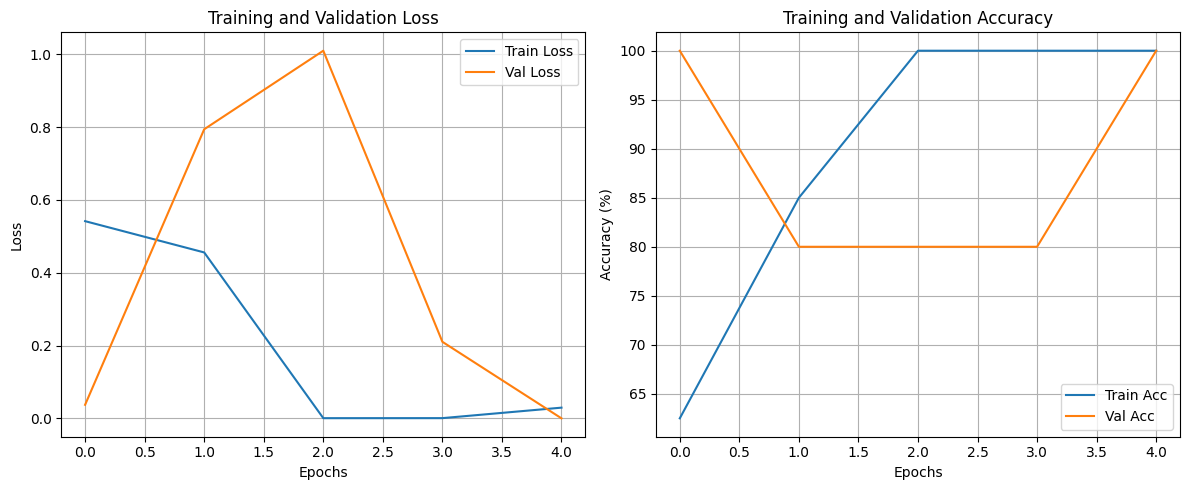

Metrics plots saved to outputs/metrics/


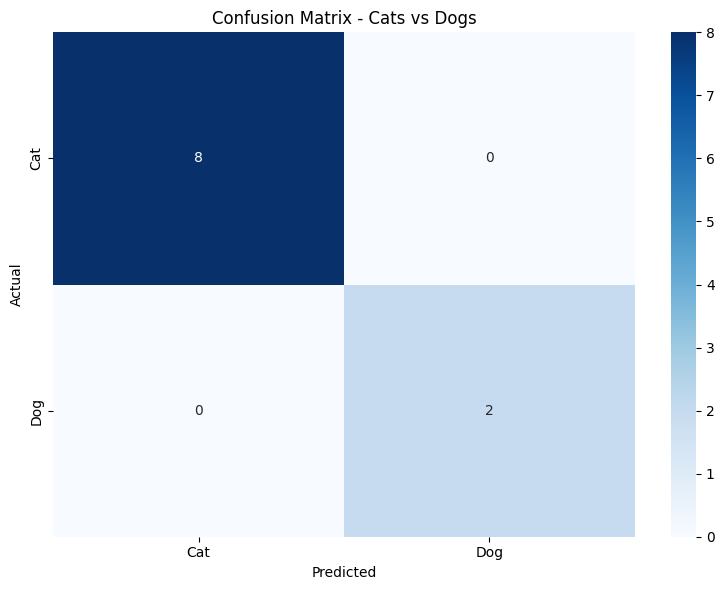

Confusion matrix saved to outputs/confusion_matrix/

Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00         8
         Dog       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



'              precision    recall  f1-score   support\n\n         Cat       1.00      1.00      1.00         8\n         Dog       1.00      1.00      1.00         2\n\n    accuracy                           1.00        10\n   macro avg       1.00      1.00      1.00        10\nweighted avg       1.00      1.00      1.00        10\n'

In [18]:
# Create trainer and train
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    lr=0.001,
    epochs=5  # Start with 5 epochs for testing, increase to 15 for better results
)

# Train the model
train_losses, val_losses, train_accs, val_accs = trainer.train()

# Final evaluation
print("\n" + "="*50)
print("📊 FINAL EVALUATION")
print("="*50)
val_loss, val_acc, cm, all_labels, all_preds = trainer.validate()

# Plot metrics
trainer.plot_metrics()
trainer.plot_confusion_matrix(cm)
trainer.generate_classification_report(all_labels, all_preds)

In [19]:
# Save model to Google Drive
import shutil

# Create a directory in Drive
!mkdir -p /content/drive/MyDrive/cats_dogs_model

# Copy model files
!cp models/*.pth /content/drive/MyDrive/cats_dogs_model/

print("✅ Model saved to Google Drive!")
print("📂 Location: My Drive/cats_dogs_model/")

✅ Model saved to Google Drive!
📂 Location: My Drive/cats_dogs_model/


In [20]:
class InferenceEngine:
    def __init__(self, model_path, device='cuda'):
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')

        # Load model
        checkpoint = torch.load(model_path, map_location=self.device)
        self.model = CatsDogsClassifier(num_classes=2).to(self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        self.class_names = ['Cat', 'Dog']

    def predict_single(self, image_path):
        image = Image.open(image_path).convert('RGB')
        input_tensor = self.transform(image).unsqueeze(0).to(self.device)

        with torch.no_grad():
            output = self.model(input_tensor)
            probabilities = torch.softmax(output, dim=1)
            predicted_class = torch.argmax(probabilities, dim=1).item()
            confidence = probabilities[0][predicted_class].item()

        return predicted_class, confidence, image

    def visualize_predictions(self, image_paths, save_path='outputs/sample_predictions/'):
        os.makedirs(save_path, exist_ok=True)

        results = []
        for path in image_paths:
            pred_class, confidence, img = self.predict_single(path)
            results.append({
                'path': path,
                'class_name': self.class_names[pred_class],
                'confidence': confidence,
                'image': img
            })

        # Display images
        n_images = len(results)
        cols = min(5, n_images)
        rows = (n_images + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
        if rows == 1:
            axes = [axes] if cols == 1 else axes
        else:
            axes = axes.flatten()

        for idx, result in enumerate(results):
            ax = axes[idx]
            img = result['image']
            pred_class = result['class_name']
            confidence = result['confidence']

            ax.imshow(img)
            ax.set_title(f"{pred_class}\n({confidence:.2%})", fontsize=12)
            ax.axis('off')

        for idx in range(n_images, len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(save_path, 'predictions.png'), dpi=300)
        plt.show()
        print(f"Predictions saved to {save_path}")

        return results

In [21]:
# Find the latest model file
model_files = sorted([f for f in os.listdir('models/') if f.endswith('.pth')])
if model_files:
    latest_model = os.path.join('models/', model_files[-1])
    print(f"Using model: {latest_model}")

    # Create inference engine
    engine = InferenceEngine(latest_model, device='cuda')

    # Get test images from dataset
    test_images = []
    for class_name in ['cat', 'dog']:
        class_dir = os.path.join('data', class_name)
        if os.path.exists(class_dir):
            imgs = [os.path.join(class_dir, f) for f in os.listdir(class_dir)[:5]]
            test_images.extend(imgs)

    if test_images:
        print(f"\n🔍 Running inference on {len(test_images)} images...")
        results = engine.visualize_predictions(test_images[:10])

        # Print results
        print("\n📊 PREDICTION RESULTS:")
        print("=" * 50)
        for i, result in enumerate(results):
            print(f"{i+1}. {os.path.basename(result['path'])}: {result['class_name']} ({result['confidence']:.2%})")
    else:
        print("No test images found!")
else:
    print("No model found! Train the model first.")

Using model: models/best_model_20260903_173948.pth


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


No test images found!


📤 Upload images to test...


Saving images.jpg to images.jpg


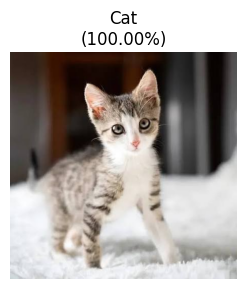

Predictions saved to outputs/sample_predictions/

📊 UPLOADED IMAGE RESULTS:
1. Cat (100.00%)


In [22]:
from google.colab import files
import io
from PIL import Image

# Upload images from your computer
print("📤 Upload images to test...")
uploaded = files.upload()

# Process uploaded images
test_images = []
for filename, content in uploaded.items():
    # Save uploaded image
    with open(filename, 'wb') as f:
        f.write(content)
    test_images.append(filename)

if test_images:
    # Run inference on uploaded images
    results = engine.visualize_predictions(test_images)

    print("\n📊 UPLOADED IMAGE RESULTS:")
    print("=" * 50)
    for i, result in enumerate(results):
        print(f"{i+1}. {result['class_name']} ({result['confidence']:.2%})")
else:
    print("No images uploaded!")

In [23]:
# Create a zip of all results
!zip -r results.zip outputs/ models/*.pth

# Download the zip file
from google.colab import files
files.download('results.zip')

print("✅ Results downloaded!")

  adding: outputs/ (stored 0%)
  adding: outputs/confusion_matrix/ (stored 0%)
  adding: outputs/confusion_matrix/confusion_matrix.png (deflated 33%)
  adding: outputs/metrics/ (stored 0%)
  adding: outputs/metrics/classification_report.txt (deflated 66%)
  adding: outputs/metrics/training_metrics.png (deflated 12%)
  adding: outputs/sample_predictions/ (stored 0%)
  adding: outputs/sample_predictions/predictions.png (deflated 7%)
  adding: models/best_model_20260903_173948.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Results downloaded!


In [24]:
print("=" * 60)
print("🐱🐶 CATS VS DOGS CLASSIFIER - PROJECT COMPLETE")
print("=" * 60)
print(f"\n✅ Best Validation Accuracy: {trainer.best_val_acc:.2f}%")

print("\n📁 OUTPUTS GENERATED:")
print("  - Trained model: models/best_model_*.pth")
print("  - Training metrics: outputs/metrics/training_metrics.png")
print("  - Confusion matrix: outputs/confusion_matrix/confusion_matrix.png")
print("  - Sample predictions: outputs/sample_predictions/predictions.png")
print("  - Classification report: outputs/metrics/classification_report.txt")

print("\n📤 FILES EXPORTED:")
print("  - Downloaded results.zip")
print("  - Model saved to Google Drive")

print("\n🎯 NEXT STEPS:")
print("  1. Download results.zip")
print("  2. Check your Google Drive for model backup")
print("  3. Upload more images to test")
print("  4. Share your results on GitHub/LinkedIn")

print("\n" + "=" * 60)
print("🌟 PROJECT COMPLETE! CONGRATULATIONS! 🎉")
print("=" * 60)

🐱🐶 CATS VS DOGS CLASSIFIER - PROJECT COMPLETE

✅ Best Validation Accuracy: 100.00%

📁 OUTPUTS GENERATED:
  - Trained model: models/best_model_*.pth
  - Training metrics: outputs/metrics/training_metrics.png
  - Confusion matrix: outputs/confusion_matrix/confusion_matrix.png
  - Sample predictions: outputs/sample_predictions/predictions.png
  - Classification report: outputs/metrics/classification_report.txt

📤 FILES EXPORTED:
  - Downloaded results.zip
  - Model saved to Google Drive

🎯 NEXT STEPS:
  1. Download results.zip
  2. Check your Google Drive for model backup
  3. Upload more images to test
  4. Share your results on GitHub/LinkedIn

🌟 PROJECT COMPLETE! CONGRATULATIONS! 🎉
